In [1]:
# Import Dataset
import pandas as pd

# load data
df = pd.read_csv("Data Aktual Penumpang MTA.csv")

# lihat data
df.head(16529)

,Date,Mode,Count
0,3/1/2020,AAR,"19,922"
1,3/1/2020,Subway,"2,212,965"
2,3/1/2020,SIR,"1,636"
3,3/1/2020,LIRR,"86,790"
4,3/1/2020,Bus,"984,908"
...,...,...,...
16524,4/9/2026,SIR,"7,418"
16525,4/9/2026,Bus,"1,229,949"
16526,4/9/2026,BT,"906,459"
16527,4/9/2026,Subway,"4,099,280"


In [2]:
# Data Quality Check
print("=== INFO ===")
print(df.info())

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(df.duplicated().sum())


# Tahap Cleaning

# Convert Date ke datetime
df['Date'] = pd.to_datetime(df['Date'])

# Bersihkan Count (dari koma ke numerik)
# pastikan dulu jadi string sebelum replace agar tidak error
df['Count'] = (
    df['Count']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Drop missing di Count saja
df = df.dropna(subset=['Count'])


# Agregasi menjadi bulanan

# Kelompokkan data harian menjadi bulanan (MS = Month Start)
monthly = df.groupby([pd.Grouper(key='Date', freq='MS'), 'Mode'])['Count'].sum().reset_index()

# Rename kolom Date menjadi Month agar sinkron
monthly.rename(columns={'Date': 'Month'}, inplace=True)


# Validasi akhir
print("\n=== AFTER CLEANING & AGGREGATION ===")
print(f"Jumlah baris harian: {len(df)}")
print(f"Jumlah baris bulanan (monthly): {len(monthly)}")

print("\n=== DATA TYPES ===")
print(monthly.dtypes)

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16529 entries, 0 to 16528
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    16529 non-null  object
 1   Mode    16529 non-null  object
 2   Count   16495 non-null  object
dtypes: object(3)
memory usage: 387.5+ KB
None

=== MISSING VALUES ===
Date      0
Mode      0
Count    34
dtype: int64

=== DUPLICATES ===
0

=== AFTER CLEANING & AGGREGATION ===
Jumlah baris harian: 16495
Jumlah baris bulanan (monthly): 550

=== DATA TYPES ===
Month    datetime64[ns]
Mode             object
Count           float64
dtype: object


In [3]:
# Sudah dijumlahkan dari hari ke bulan
display(
    monthly
    .style
    .format({
        'Count': '{:,.0f}',
        'Month': lambda x: x.strftime('%Y-%m-%d')
    })
    .set_table_attributes(
        "style='display:block; max-height:400px; overflow-y:auto;'"
    )
)

,Month,Mode,Count
0,2020-03-01,AAR,"558,330"
1,2020-03-01,BT,"16,690,214"
2,2020-03-01,Bus,"31,871,784"
3,2020-03-01,LIRR,"3,625,224"
4,2020-03-01,MNR,"3,890,767"
5,2020-03-01,SIR,"200,584"
6,2020-03-01,Subway,"73,625,223"
7,2020-04-01,AAR,"181,852"
8,2020-04-01,BT,"8,434,326"
9,2020-04-01,Bus,"471,515"


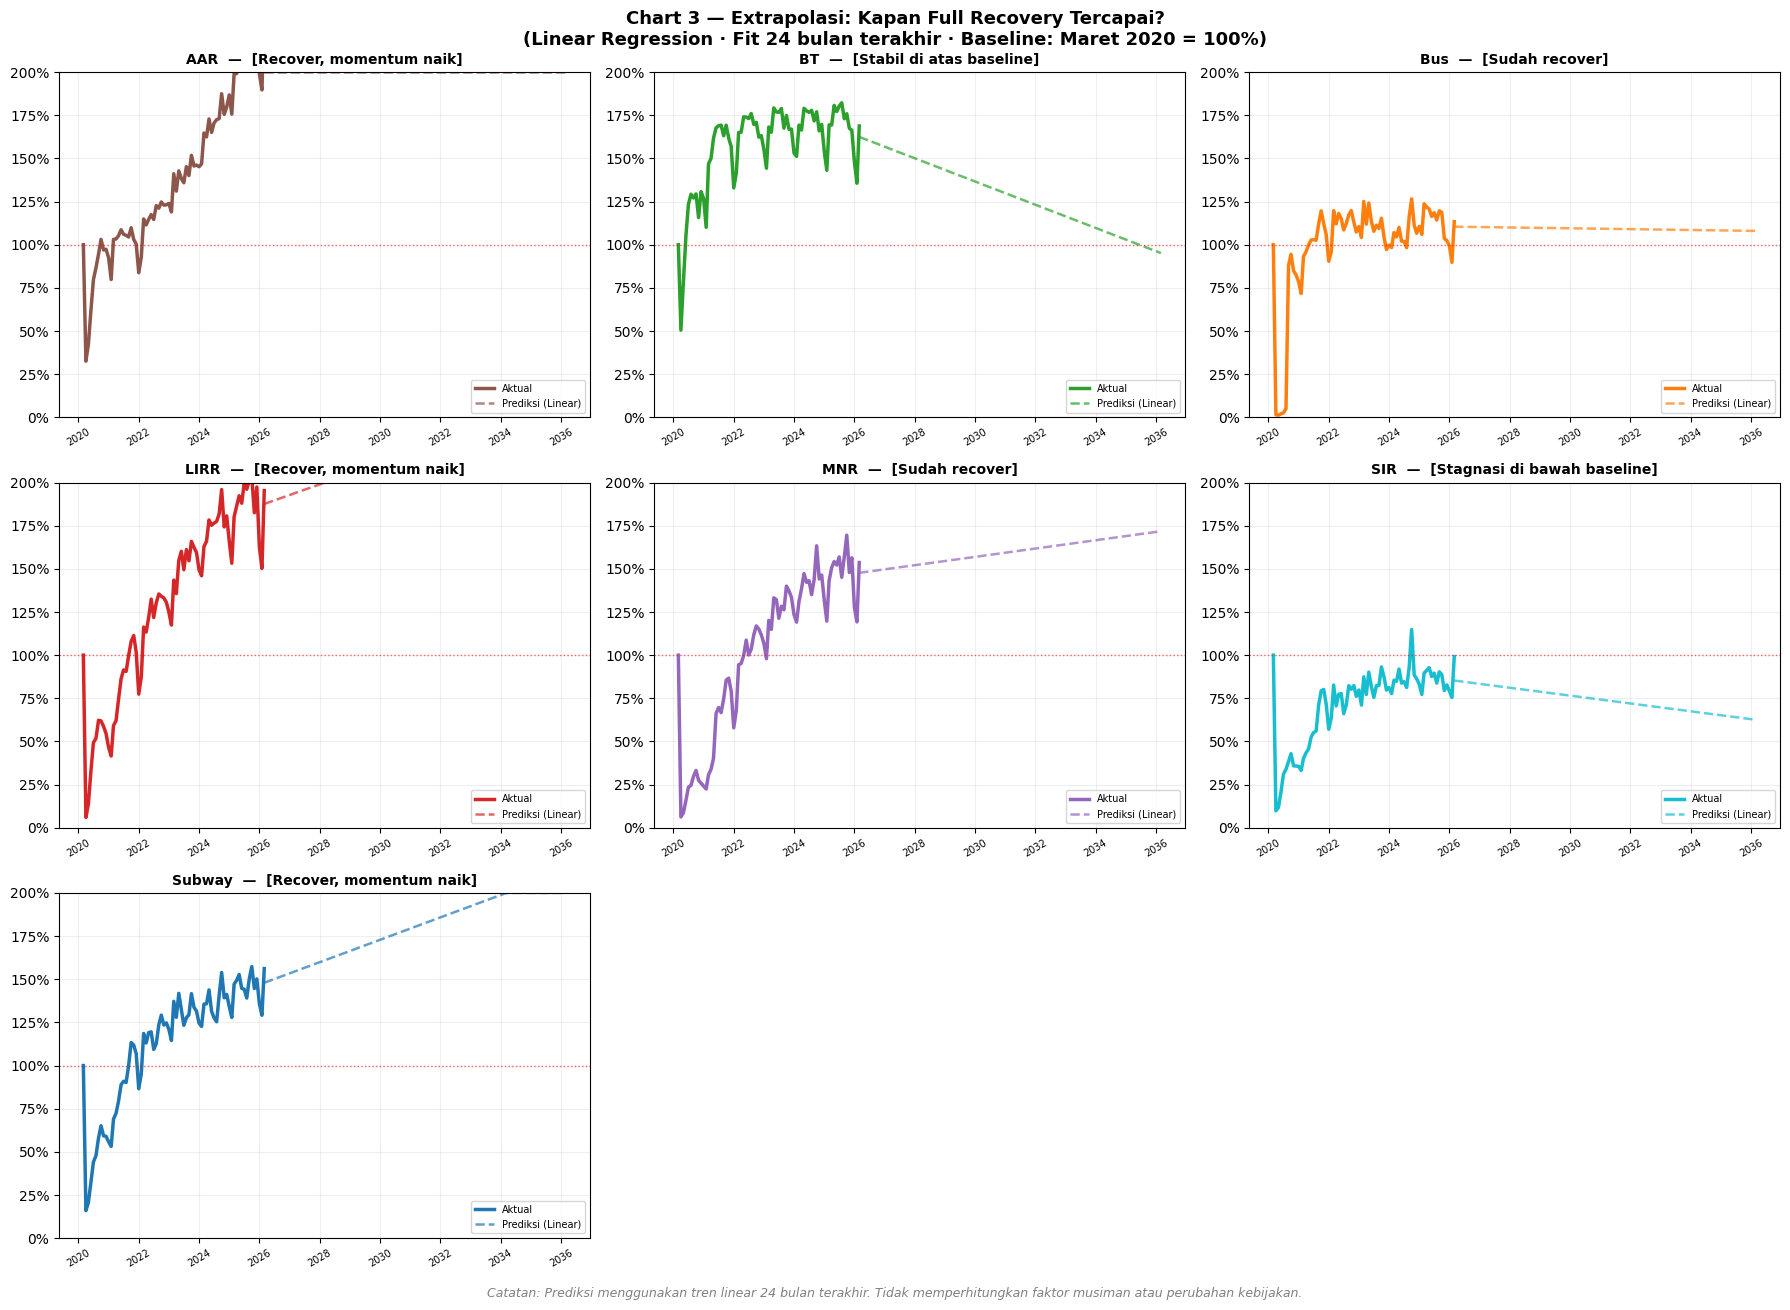

In [4]:
# CHART 3: Extrapolasi — Kapan Full Recovery Tercapai? (Linear Regression)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Siapkan data recovery %
df_wide  = monthly.pivot(index='Month', columns='Mode', values='Count')
df_wide  = df_wide.iloc[:-1]       # buang April 2026 (parsial)
baseline = df_wide.iloc[0]         # Maret 2020 = 100%
df_rec   = (df_wide / baseline) * 100

# Exclude CBD & CRZ (tidak punya baseline Maret 2020 yang valid)
modes_to_model = [m for m in df_rec.columns
                  if m not in ('CBD Entries', 'CRZ Entries')]

# Konfigurasi
N_FIT_MONTHS = 24    # fit 24 bulan terakhir → tangkap tren terkini
N_FUTURE     = 120   # prediksi 10 tahun ke depan

color_map = {
    'Subway': '#1f77b4', 'Bus': '#ff7f0e', 'BT': '#2ca02c',
    'LIRR':   '#d62728', 'MNR': '#9467bd', 'AAR': '#8c564b', 'SIR': '#17becf',
}

# Plot
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

for idx, mode in enumerate(modes_to_model):
    ax     = axes[idx]
    series = df_rec[mode].dropna()
    color  = color_map.get(mode, 'gray')

    # Fit LINEAR pada 24 bulan terakhir (degree=1 → tidak melengkung ke bawah)
    fit_series = series.iloc[-N_FIT_MONTHS:]
    t_fit      = np.arange(len(fit_series))   # 0 … 23

    coeffs    = np.polyfit(t_fit, fit_series.values, 1)  # degree=1
    slope     = coeffs[0]
    intercept = coeffs[1]
    line      = np.poly1d(coeffs)

    # Sambungkan prediksi dari titik akhir aktual
    t_join     = np.arange(len(fit_series) - 1, len(fit_series) + N_FUTURE)
    y_join     = np.clip(line(t_join), 0, 200)   # cap 0–200%
    join_dates = pd.date_range(
        start=series.index[-1], periods=len(t_join), freq='MS'
    )

    # Tentukan status & kapan hit 100%
    already_recovered = series.iloc[-1] >= 100
    hit_100 = None

    if not already_recovered:
        if slope > 0:
            t_hit = (100 - intercept) / slope
            if len(fit_series) <= t_hit < len(fit_series) + N_FUTURE:
                months_ahead = int(round(t_hit - (len(fit_series) - 1)))
                hit_100 = series.index[-1] + pd.DateOffset(months=months_ahead)

    # Title — label nuanced berdasarkan slope
    if already_recovered:
        if slope < -0.3:
            title_note = '[Stabil di atas baseline]'   # plateau, bukan declining
        elif slope > 0.5:
            title_note = '[Recover, momentum naik]'    # masih tumbuh
        else:
            title_note = '[Sudah recover]'
    elif hit_100:
        title_note = f'Est. {hit_100.strftime("%b %Y")}'
    elif slope <= 0:
        title_note = '[Stagnasi di bawah baseline]'
    else:
        title_note = '[Tidak tercapai s/d 2036]'

    # Plot aktual & prediksi
    ax.plot(series.index, series.values,
            color=color, lw=2.5, label='Aktual')
    ax.plot(join_dates, y_join,
            color=color, lw=1.8, ls='--', alpha=0.7, label='Prediksi (Linear)')

    # Referensi (set ylim dulu sebelum anotasi)
    ax.set_ylim(0, 200)
    ax.axhline(100, color='red', lw=1, ls=':', alpha=0.6)

    if hit_100:
        ax.axvline(hit_100, color='red', lw=1, ls='--', alpha=0.4)
        ax.text(hit_100, 5, hit_100.strftime('%b %Y'),
                color='red', fontsize=8, rotation=45, ha='left')

    ax.set_title(f'{mode}  —  {title_note}', fontsize=10, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, loc='lower right')

# Sembunyikan subplot kosong
for j in range(len(modes_to_model), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Chart 3 — Extrapolasi: Kapan Full Recovery Tercapai?\n'
    '(Linear Regression · Fit 24 bulan terakhir · Baseline: Maret 2020 = 100%)',
    fontsize=13, fontweight='bold'
)

# Caption metodologi
fig.text(0.5, -0.01,
         'Catatan: Prediksi menggunakan tren linear 24 bulan terakhir. '
         'Tidak memperhitungkan faktor musiman atau perubahan kebijakan.',
         ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('chart3_extrapolation.png', dpi=150, bbox_inches='tight')
plt.show()